In [1]:
library(data.table)
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
DEGs = fread('DEresults_stageE8.5_tdTom_corrFalse_pseudobulk.txt.gz')[,celltype:=variable]

In [11]:
unique(DEGs$celltype)

[1] "Allantois"                      "Allantois_endothelium"         
 [3] "Amniotic_ectoderm"              "Caudal_epiblast"               
 [5] "Dorsal_spinal_cord_progenitors" "Ectoderm"                      
 [7] "Embryo_proper_endothelium"      "Intermediate_mesoderm"         
 [9] "Kidney_primordium"              "Lateral_plate_mesoderm"        
[11] "Limb_ectoderm"                  "Limb_mesoderm"                 
[13] "NMPs"                           "NMPs_Mesoderm-biased"          
[15] "Non-neural_ectoderm"            "Optic_vesicle"                 
[17] "Paraxial_mesoderm"              "Pharyngeal_endoderm"           
[19] "Pharyngeal_mesoderm"            "Placodal_ectoderm"             
[21] "Presomitic_mesoderm"            "Somitic_mesoderm"              
[23] "Surface_ectoderm"               "Ventral_hindbrain_progenitors"

In [3]:
keep = unique(DEGs$celltype)

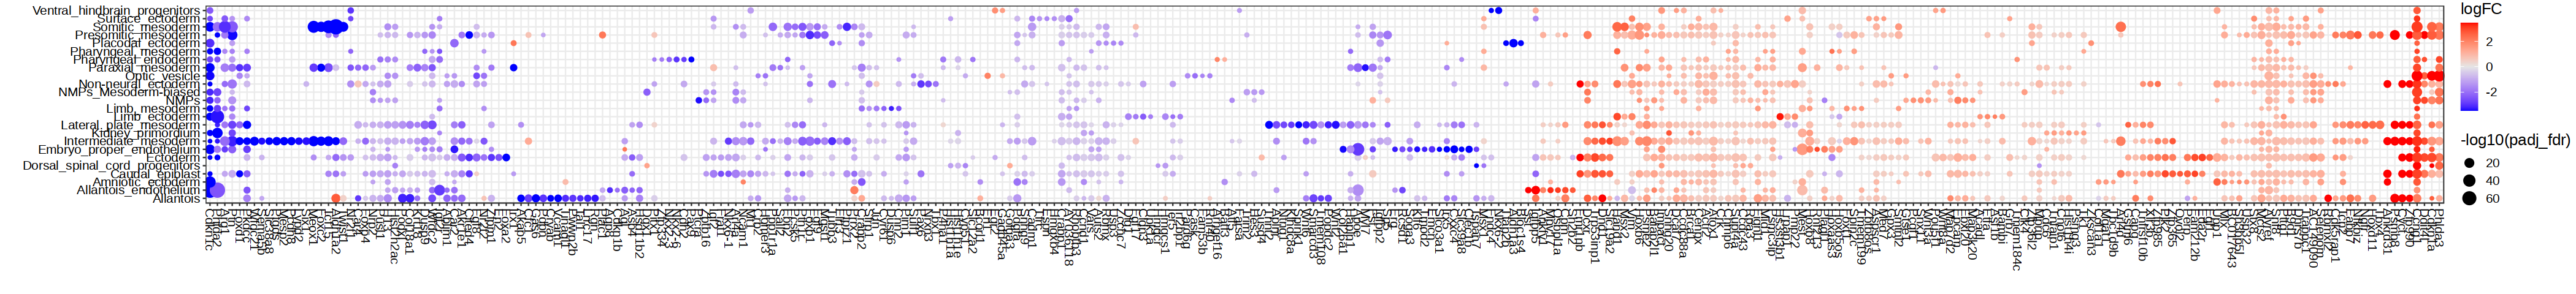

In [4]:
features = unique(DEGs[padj_fdr<0.05 & abs(logFC) > 0.75] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, 20), by=celltype] %>% .$gene

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
quantile_cutoff_FC = 0.95
quantile_cutoff_FDR = 0.001
to.plot = copy(DEGs)[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]
quantile_FC = quantile(abs(to.plot$logFC), quantile_cutoff_FC)
to.plot = to.plot %>% 
    .[, logFC := ifelse(logFC >= quantile_FC, quantile_FC, logFC)] %>% 
    .[, logFC := ifelse(logFC <= -quantile_FC, -quantile_FC, logFC)] %>% 
    .[, padj_fdr := ifelse(padj_fdr <= quantile(padj_fdr, quantile_cutoff_FDR), quantile(padj_fdr, quantile_cutoff_FDR), padj_fdr)] 

options(repr.plot.width=35, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

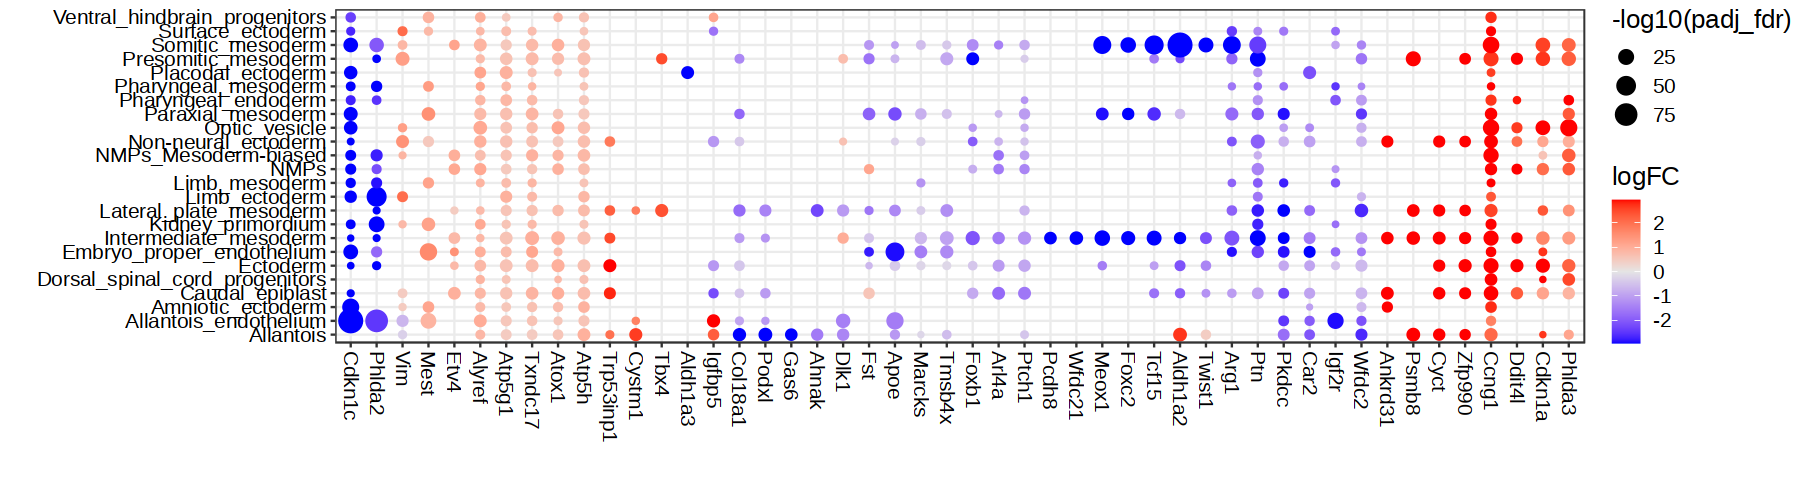

In [13]:
features = unique(DEGs[padj_fdr<1e-10 & abs(logFC) > 0.75] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, 6), by=celltype] %>% .$gene

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
quantile_cutoff_FC = 0.8
quantile_cutoff_FDR = 0.001
to.plot = copy(DEGs)[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]
quantile_FC = quantile(abs(to.plot$logFC), quantile_cutoff_FC)
to.plot = to.plot %>% 
    .[, logFC := ifelse(logFC >= quantile_FC, quantile_FC, logFC)] %>% 
    .[, logFC := ifelse(logFC <= -quantile_FC, -quantile_FC, logFC)] %>% 
    .[, padj_fdr := ifelse(padj_fdr <= quantile(padj_fdr, quantile_cutoff_FDR), quantile(padj_fdr, quantile_cutoff_FDR), padj_fdr)] 

options(repr.plot.width=15, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

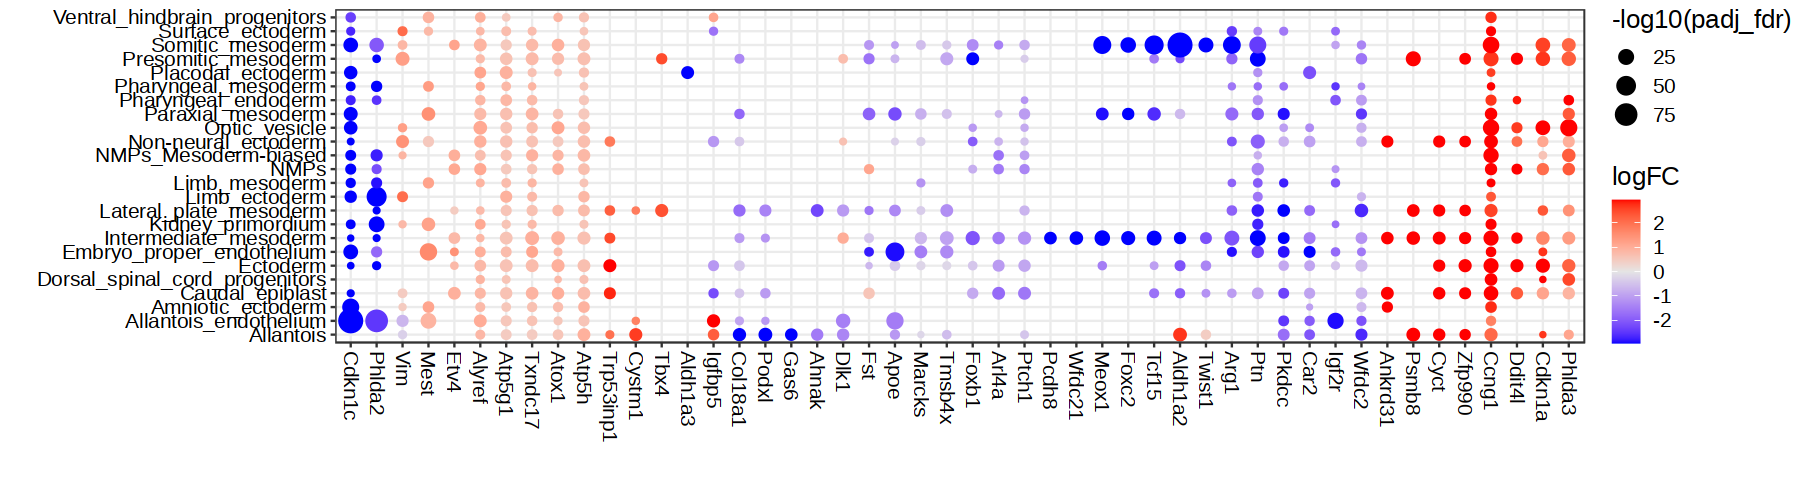

In [13]:
features = unique(DEGs[padj_fdr<1e-10 & abs(logFC) > 0.75] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, 6), by=celltype] %>% .$gene

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
quantile_cutoff_FC = 0.8
quantile_cutoff_FDR = 0.001
to.plot = copy(DEGs)[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]
quantile_FC = quantile(abs(to.plot$logFC), quantile_cutoff_FC)
to.plot = to.plot %>% 
    .[, logFC := ifelse(logFC >= quantile_FC, quantile_FC, logFC)] %>% 
    .[, logFC := ifelse(logFC <= -quantile_FC, -quantile_FC, logFC)] %>% 
    .[, padj_fdr := ifelse(padj_fdr <= quantile(padj_fdr, quantile_cutoff_FDR), quantile(padj_fdr, quantile_cutoff_FDR), padj_fdr)] 

options(repr.plot.width=15, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

In [19]:
unique(DEGs$celltype)

[1] "Allantois"                      "Allantois_endothelium"         
 [3] "Amniotic_ectoderm"              "Caudal_epiblast"               
 [5] "Dorsal_spinal_cord_progenitors" "Ectoderm"                      
 [7] "Embryo_proper_endothelium"      "Intermediate_mesoderm"         
 [9] "Kidney_primordium"              "Lateral_plate_mesoderm"        
[11] "Limb_ectoderm"                  "Limb_mesoderm"                 
[13] "NMPs"                           "NMPs_Mesoderm-biased"          
[15] "Non-neural_ectoderm"            "Optic_vesicle"                 
[17] "Paraxial_mesoderm"              "Pharyngeal_endoderm"           
[19] "Pharyngeal_mesoderm"            "Placodal_ectoderm"             
[21] "Presomitic_mesoderm"            "Somitic_mesoderm"              
[23] "Surface_ectoderm"               "Ventral_hindbrain_progenitors"

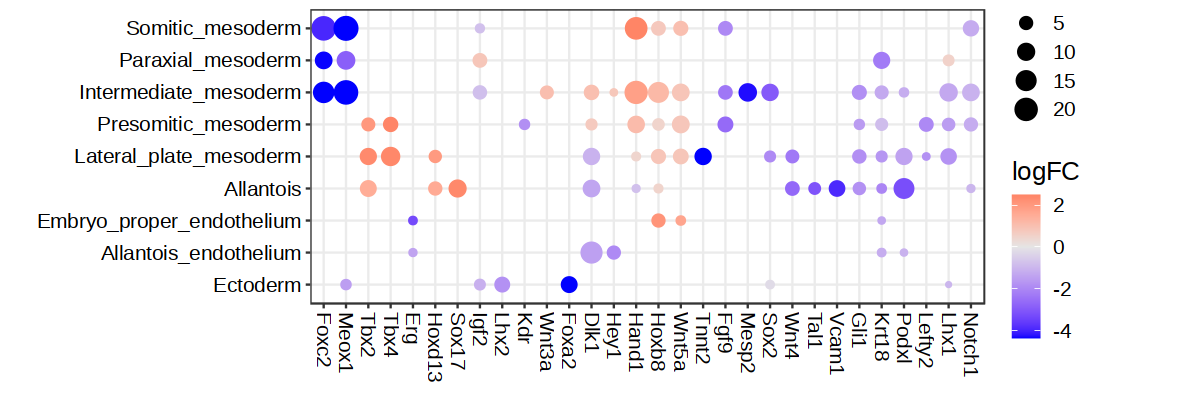

In [31]:
features = c('Podxl', 'Vcam1','Sox17', 'Wnt4', 'Tal1', 'Hey1', 
             'Notch1', 'Gli1', 'Igf2', 'Pax6', 'Foxa2', 'Lhx1', 'Lhx2', 
             'Wnt5a', 'Hoxb8', 'Erg', 'Meox1', 'Mesp2', 'Sox2', 'Tnnt2', 
             'Tbx4', 'Dlk1', 'Tbx2', 'Hoxd13', 'Wnt3a', 'Foxc2', 
             'Krt18', 'Lefty2', 'Kdr', 'Foxc2', 'Hand1', 'Fgf9')
celltype_subset = c('Ectoderm', 'Allantois_endothelium', 'Embryo_proper_endothelium', 'Allantois',
                   'Lateral_plate_mesoderm', 'Presomitic_mesoderm', 'Intermediate_mesoderm', 'Paraxial_mesoderm', 'Somitic_mesoderm')

# Turn dt in matrix
DEGs.mtx = DEGs[celltype %in% celltype_subset][gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
quantile_cutoff_FC = 0.95
quantile_cutoff_FDR = 0.001
to.plot = copy(DEGs)[gene %in% features & padj_fdr < 0.05] %>%
    .[celltype %in% celltype_subset] %>% 
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = celltype_subset)]
quantile_FC = quantile(abs(to.plot$logFC), quantile_cutoff_FC)
to.plot = to.plot %>% 
    .[, logFC := ifelse(logFC >= quantile_FC, quantile_FC, logFC)] %>% 
    .[, logFC := ifelse(logFC <= -quantile_FC, -quantile_FC, logFC)] %>% 
    .[, padj_fdr := ifelse(padj_fdr <= quantile(padj_fdr, quantile_cutoff_FDR), quantile(padj_fdr, quantile_cutoff_FDR), padj_fdr)] 

options(repr.plot.width=10, repr.plot.height=3.5)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

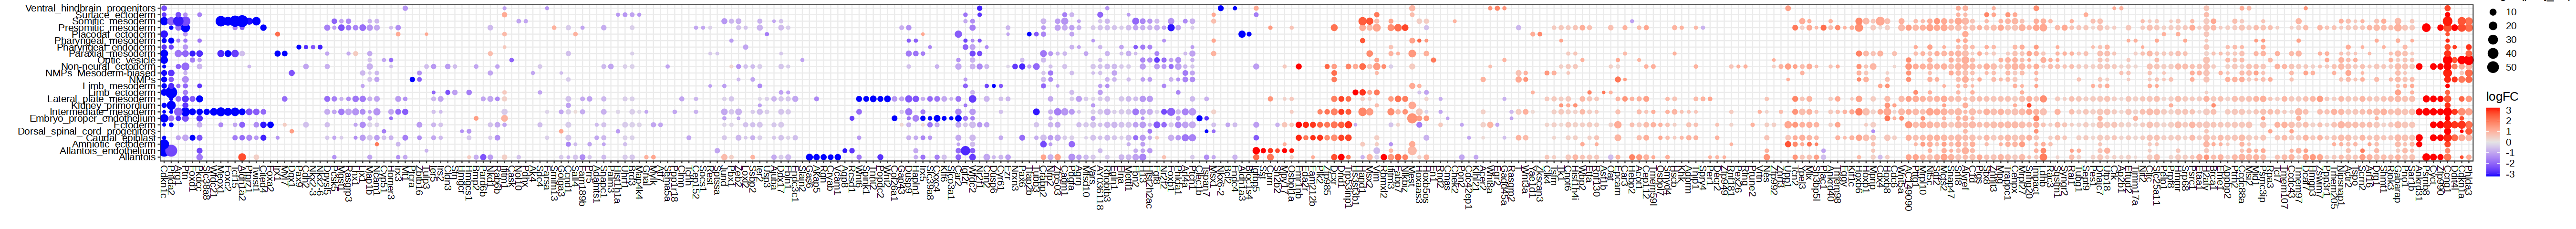

In [12]:
logFC_threshold = 1
top_x = 10
features = c(unique(DEGs[padj_fdr<0.05 & abs(logFC) > logFC_threshold] %>% .[order(-abs(logFC)), ]) %>% .[,head(.SD, top_x), by=celltype] %>% .$gene,
             unique(DEGs[padj_fdr<0.05 & abs(logFC) > logFC_threshold] %>% .[order(abs(logFC)), ]) %>% .[,head(.SD, top_x), by=celltype] %>% .$gene)

# Turn dt in matrix
DEGs.mtx = DEGs[gene %in% features ,c('gene',  'logFC', 'celltype')] %>% dcast(., celltype ~ gene, value.var = 'logFC')
DEGs.mtx[is.na(DEGs.mtx)] = 0
DEGs.mtx = DEGs.mtx %>% as.data.frame() %>% tibble::column_to_rownames('celltype')

# Cluster genes by logFC
order = hclust(dist(t(DEGs.mtx)))

# prepare data.table for plotting
quantile_cutoff_FC = 0.95
quantile_cutoff_FDR = 0.001
to.plot = copy(DEGs)[gene %in% features & padj_fdr < 0.05] %>%
    .[, gene := factor(gene, levels = order$labels[order$order])] %>%
    .[, celltype := factor(celltype, levels = keep)]
quantile_FC = quantile(abs(to.plot$logFC), quantile_cutoff_FC)
to.plot = to.plot %>% 
    .[, logFC := ifelse(logFC >= quantile_FC, quantile_FC, logFC)] %>% 
    .[, logFC := ifelse(logFC <= -quantile_FC, -quantile_FC, logFC)] %>% 
    .[, padj_fdr := ifelse(padj_fdr <= quantile(padj_fdr, quantile_cutoff_FDR), quantile(padj_fdr, quantile_cutoff_FDR), padj_fdr)] 

options(repr.plot.width=45, repr.plot.height=4)
ggplot(to.plot, aes(gene, celltype, size=-log10(padj_fdr), col=logFC)) + 
    geom_point() + 
    scale_color_gradient2(low='blue', mid = 'gray90', high='red', name='logFC') + 
    xlab('') + ylab('') + 
    theme_bw() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(size=12, color='black'),
         text=element_text(size=15))

In [13]:
DEGs[gene=='Zfp462']

logFC,logCPM,F,PValue,padj_fdr,gene,variable,stage,sig,celltype
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<lgl>,<chr>
0.296929321,5.853355,4.413025968,0.04349431,0.1218356,Zfp462,Allantois,E8.5,FALSE,Allantois
0.277387756,4.557341,0.367199513,0.54455539,0.8521466,Zfp462,Allantois_endothelium,E8.5,FALSE,Allantois_endothelium
0.247099148,7.602237,2.006380102,0.16214001,0.5115940,Zfp462,Amniotic_ectoderm,E8.5,FALSE,Amniotic_ectoderm
-0.157394737,5.951225,1.807044505,0.18836048,0.4040819,Zfp462,Caudal_epiblast,E8.5,FALSE,Caudal_epiblast
0.315720277,6.546474,0.746091657,0.38774937,0.9000724,Zfp462,Dorsal_spinal_cord_progenitors,E8.5,FALSE,Dorsal_spinal_cord_progenitors
0.006229473,6.583043,0.005968899,0.93892700,0.9718539,Zfp462,Ectoderm,E8.5,FALSE,Ectoderm
-0.076286688,5.551832,0.024864532,0.87471077,0.9661675,Zfp462,Embryo_proper_endothelium,E8.5,FALSE,Embryo_proper_endothelium
-0.115541422,4.788497,0.448244421,0.50686709,0.6920070,Zfp462,Intermediate_mesoderm,E8.5,FALSE,Intermediate_mesoderm
0.295661615,6.206813,0.323325444,0.56965344,0.9381882,Zfp462,Kidney_primordium,E8.5,FALSE,Kidney_primordium
